# Initial modelling — Week 3

Working through the supplied NSW1 half-hourly data, rather than the synthetic sample.
The main outcome is the change in operational demand in MW. The explanatory models
use PV changes from the same interval; the forecasts predict the next interval.
These are different questions, so their errors are reported separately.

The existing Week 3 workbook already contains monthly, half-hourly and seasonal
summaries. The plots here use the training year only. Working notes and saved
figures are in `week_3_modelling_notes.md` and `week_3_plots/`.

## 1. Load modelling dataset

Run from `src/` with the packages in `../requirements.txt`. Timestamps have no time
zone in the supplied CSV. Keep their existing clock for now; do not guess a daylight
saving conversion. Weather is joined by calendar date, including at midnight.
The interval-ending convention and weather observation dates still need checking.

In [1]:
from pathlib import Path
import sys
import importlib.metadata as metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.gam.api import GLMGam, BSplines
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import HistGradientBoostingRegressor
from IPython.display import display

pd.set_option('display.max_columns', 15)
PLOT_DIR = Path('week_3_plots')
PLOT_DIR.mkdir(exist_ok=True)


def load_data(file_path):
    data = pd.read_csv(file_path, parse_dates=['DATETIME'])
    if data['DATETIME'].isna().any() or data['DATETIME'].duplicated().any():
        raise ValueError('Resolve missing or duplicate timestamps first.')
    return data.sort_values('DATETIME').reset_index(drop=True)


def save_plot(figure, name):
    figure.tight_layout()
    figure.savefig(PLOT_DIR / name, dpi=140, bbox_inches='tight')
    plt.show()
    plt.close(figure)


data = load_data('../data/NSW1_Historical_Modelling_Dataset_Week3.csv')
print('Python:', sys.version.split()[0])
for package in ['pandas', 'numpy', 'matplotlib', 'statsmodels', 'scikit-learn']:
    print(package, metadata.version(package))
print('Rows:', len(data), '| Range:', data['DATETIME'].min(), 'to', data['DATETIME'].max())

Python: 3.14.1
pandas 3.0.6
numpy 2.5.3
matplotlib 3.11.2
statsmodels 0.15.0
scikit-learn 1.9.1
Rows: 19008 | Range: 2025-08-01 00:00:00 to 2026-08-31 23:30:00


## 2. Sanity checks, changes and splits

Keep missing PV values missing. Recalculate the supplied changes and lags so that
the first row does not rely on observations outside this file. `PV_LAG_1` in the
CSV is a lag of the PV **level**, not a lag of its change. The missing PV row is
labelled “No change” in the source; that label is not used here.

Use 1 August 2025–31 July 2026 for training, 1–15 August 2026 for validation and
16–31 August 2026 for testing. Forecast splits use the **target** timestamp.
All model and feature choices below use training or validation, not the test set.

In [2]:
def lag_values(data, column, lag):
    # A row shift is only a time lag when every intervening interval is present.
    steps = data['DATETIME'].diff().eq(pd.Timedelta(minutes=30))
    consecutive = steps.rolling(lag).sum().eq(lag)
    return data[column].shift(lag).where(consecutive)


def add_changes(data):
    data = data.sort_values('DATETIME').copy()
    if data['DATETIME'].isna().any() or data['DATETIME'].duplicated().any():
        raise ValueError('Resolve missing or duplicate timestamps first.')
    consecutive = data['DATETIME'].diff().eq(pd.Timedelta(minutes=30))
    data['DEMAND_CHANGE_MW'] = data['OPERATIONAL_DEMAND_MW'].diff().where(consecutive)
    data['PV_CHANGE_MW'] = data['ROOFTOP_PV_MW'].diff().where(consecutive)
    for lag in range(1, 5):
        data[f'PV_CHANGE_LAG_{lag}'] = lag_values(data, 'PV_CHANGE_MW', lag)
    data['DEMAND_CHANGE_LAG_1'] = lag_values(data, 'DEMAND_CHANGE_MW', 1)
    data['DEMAND_LAG_48'] = lag_values(data, 'OPERATIONAL_DEMAND_MW', 48)
    data['PREVIOUS_PV_QUALITY'] = lag_values(data, 'PV_QUALITY_INDICATOR', 1)
    next_interval = data['DATETIME'].shift(-1) - data['DATETIME'] == pd.Timedelta(minutes=30)
    data['TARGET_TIME'] = data['DATETIME'].shift(-1).where(next_interval)
    data['TARGET_CHANGE_MW'] = data['DEMAND_CHANGE_MW'].shift(-1).where(next_interval)
    return data


print('Duplicate timestamps:', data['DATETIME'].duplicated().sum())
print('Missing half-hours:', len(pd.date_range(data['DATETIME'].min(), data['DATETIME'].max(), freq='30min').difference(data['DATETIME'])))
print('Missing values:')
display(data.isna().sum().loc[lambda counts: counts > 0].to_frame('Missing rows'))
print('PV quality flags:')
display(data['PV_QUALITY_INDICATOR'].value_counts(dropna=False).sort_index())
print('Weather date matches interval date:', (pd.to_datetime(data['DATE']).dt.normalize() == data['DATETIME'].dt.normalize()).all())
print('Missing PV source row:')
display(data.loc[data['ROOFTOP_PV_MW'].isna(), ['DATETIME', 'PV_QUALITY_INDICATOR', 'PV_RAMP_DIRECTION']])

data = add_changes(data)
for old, new in [('DELTA_PV_MW', 'PV_CHANGE_MW'), ('DELTA_DEMAND_MW', 'DEMAND_CHANGE_MW')]:
    matched = data[[old, new]].dropna()
    print(old, 'maximum difference where both exist:', (matched[old] - matched[new]).abs().max())
for lag in [1, 2, 4]:
    for prefix, column in [('PV', 'ROOFTOP_PV_MW'), ('DEMAND', 'OPERATIONAL_DEMAND_MW')]:
        expected = lag_values(data, column, lag)
        print(f'{prefix}_LAG_{lag}', 'maximum difference:', (data[f'{prefix}_LAG_{lag}'] - expected).abs().max())

VALIDATION_START = pd.Timestamp('2026-08-01')
TEST_START = pd.Timestamp('2026-08-16')
train = data.loc[data['DATETIME'] < VALIDATION_START].copy()
validation = data.loc[(data['DATETIME'] >= VALIDATION_START) & (data['DATETIME'] < TEST_START)].copy()
print('Explanatory rows before missing-value exclusions:', len(train), 'training;', len(validation), 'validation')

Duplicate timestamps: 0
Missing half-hours: 0
Missing values:


,Missing rows
ROOFTOP_PV_MW,1
MAX_TEMP_C,48
RAINFALL_MM,528
SUNSHINE_HOURS,1344
CLOUD_9AM_OKTAS,288
CLOUD_3PM_OKTAS,672
PV_LAG_1,1
PV_LAG_2,1
PV_LAG_4,1
DELTA_PV_MW,2


PV quality flags:


PV_QUALITY_INDICATOR
0.0        1
0.7      133
1.0    18874
Name: count, dtype: int64

Weather date matches interval date: True
Missing PV source row:


,DATETIME,PV_QUALITY_INDICATOR,PV_RAMP_DIRECTION
417,2025-08-09 16:30:00,0.0,No change


DELTA_PV_MW maximum difference where both exist: 2.2737367544323206e-13
DELTA_DEMAND_MW maximum difference where both exist: 0.0
PV_LAG_1 maximum difference: 0.0
DEMAND_LAG_1 maximum difference: 0.0
PV_LAG_2 maximum difference: 0.0
DEMAND_LAG_2 maximum difference: 0.0
PV_LAG_4 maximum difference: 0.0
DEMAND_LAG_4 maximum difference: 0.0
Explanatory rows before missing-value exclusions: 17520 training; 720 validation


## 3. Exploratory relationships — training period

Daily weather values are repeated over the half-hours. Count weather coverage in
days as well as rows. Sydney Airport weather is a local proxy, not a measurement
of weather across all NSW rooftop systems.

Demand and PV summary (MW):


,OPERATIONAL_DEMAND_MW,ROOFTOP_PV_MW,DEMAND_CHANGE_MW,PV_CHANGE_MW
count,17520.00,17519.00,17519.00,17517.00
mean,7537.81,1178.44,0.02,0.06
std,1484.88,1632.93,266.95,284.88
min,2848.00,0.00,-1803.00,-1401.57
25%,6632.75,0.00,-177.00,-32.18
50%,7451.00,16.20,-64.00,0.00
75%,8424.00,2271.05,145.00,20.86
max,13182.00,5864.44,1151.00,1992.77


Weather summary (one row per date):


,count,mean,std,min,max
MIN_TEMP_C,365.0,15.60,4.14,5.9,23.9
MAX_TEMP_C,364.0,24.05,5.35,13.6,42.7
RAINFALL_MM,354.0,3.21,9.57,0.0,104.4
SUNSHINE_HOURS,339.0,7.00,3.97,0.0,13.2
RH_9AM_PCT,365.0,67.68,17.78,21.0,97.0
CLOUD_9AM_OKTAS,359.0,4.30,2.80,0.0,8.0
RH_3PM_PCT,365.0,55.50,19.89,10.0,96.0
CLOUD_3PM_OKTAS,353.0,4.56,2.70,0.0,8.0
SOLAR_EXPOSURE_MJ_M2,365.0,16.64,7.12,3.6,31.9


Missing weather days:


,Days
MIN_TEMP_C,0
MAX_TEMP_C,1
RAINFALL_MM,11
SUNSHINE_HOURS,26
RH_9AM_PCT,0
CLOUD_9AM_OKTAS,6
RH_3PM_PCT,0
CLOUD_3PM_OKTAS,12
SOLAR_EXPOSURE_MJ_M2,0


Seasonal means:


,OPERATIONAL_DEMAND_MW,ROOFTOP_PV_MW
SEASON,,
Autumn,7365.6,1027.9
Spring,6828.5,1405.6
Summer,7491.9,1482.8
Winter,8456.5,806.4


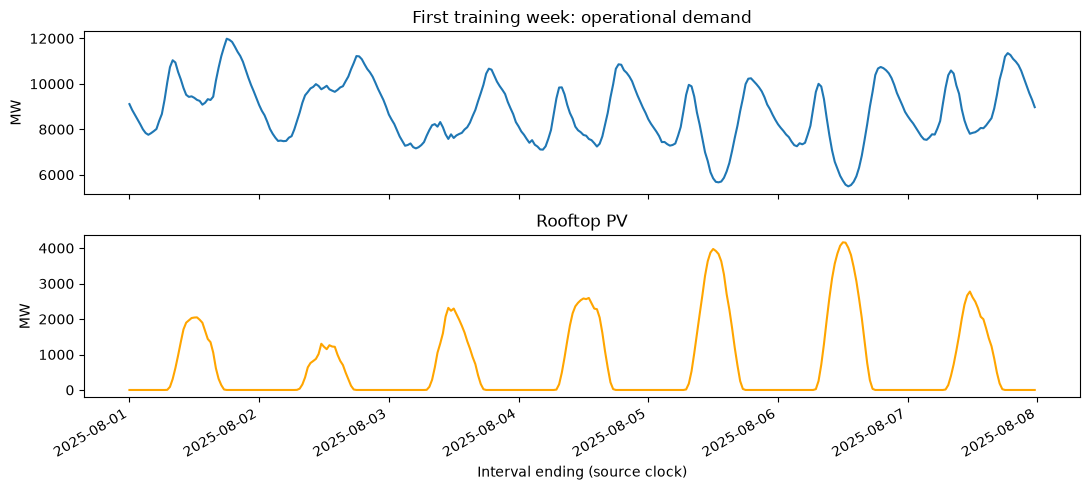

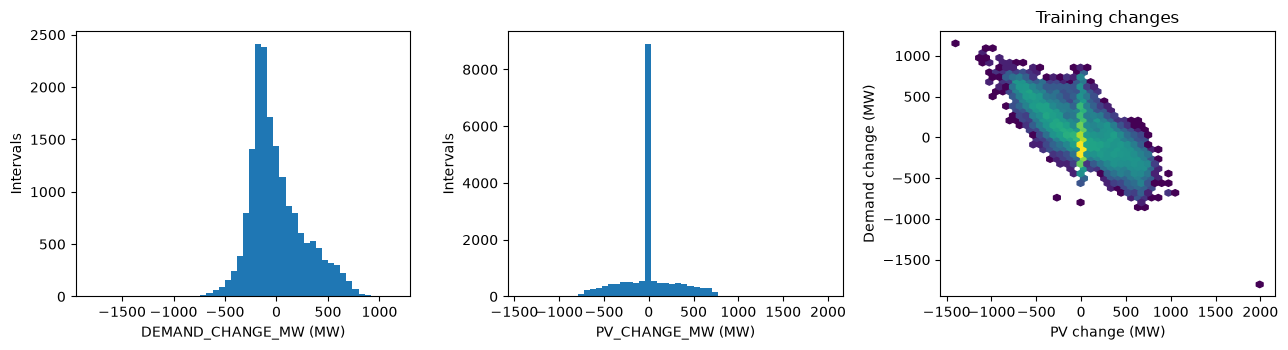

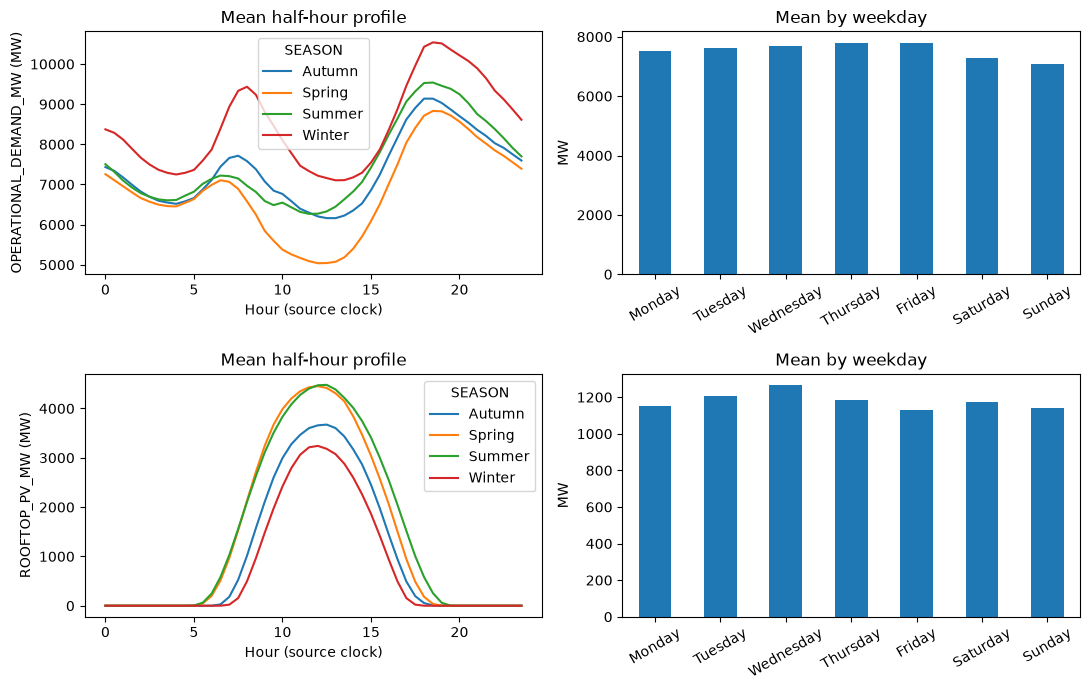

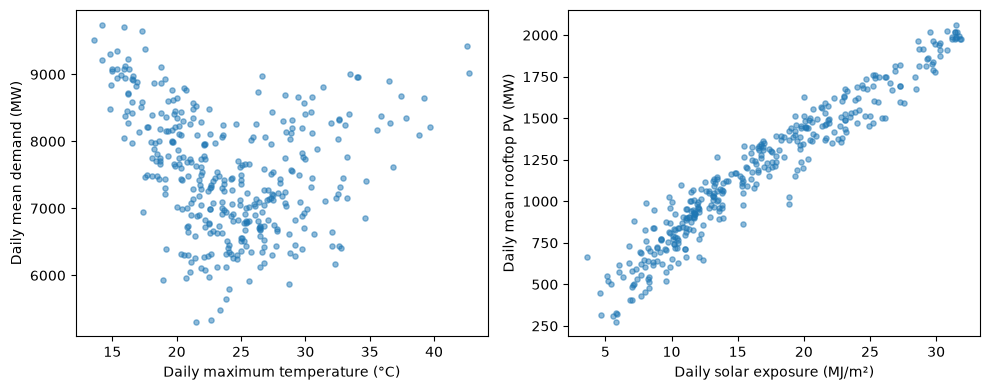

In [3]:
weather_columns = ['MIN_TEMP_C', 'MAX_TEMP_C', 'RAINFALL_MM', 'SUNSHINE_HOURS',
                   'RH_9AM_PCT', 'CLOUD_9AM_OKTAS', 'RH_3PM_PCT', 'CLOUD_3PM_OKTAS',
                   'SOLAR_EXPOSURE_MJ_M2']
print('Demand and PV summary (MW):')
display(train[['OPERATIONAL_DEMAND_MW', 'ROOFTOP_PV_MW', 'DEMAND_CHANGE_MW', 'PV_CHANGE_MW']].describe().round(2))
daily_weather = train.groupby('DATE')[weather_columns].first()
print('Weather summary (one row per date):')
display(daily_weather.describe().T[['count', 'mean', 'std', 'min', 'max']].round(2))
print('Missing weather days:')
display(daily_weather.isna().sum().to_frame('Days'))
print('Seasonal means:')
display(train.groupby('SEASON')[['OPERATIONAL_DEMAND_MW', 'ROOFTOP_PV_MW']].mean().round(1))


def plot_first_week(data):
    week = data.head(48 * 7)
    figure, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    axes[0].plot(week['DATETIME'], week['OPERATIONAL_DEMAND_MW'])
    axes[0].set(title='First training week: operational demand', ylabel='MW')
    axes[1].plot(week['DATETIME'], week['ROOFTOP_PV_MW'], color='orange')
    axes[1].set(title='Rooftop PV', xlabel='Interval ending (source clock)', ylabel='MW')
    figure.autofmt_xdate()
    save_plot(figure, '01_first_week.png')


plot_first_week(train)
figure, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for axis, column in zip(axes[:2], ['DEMAND_CHANGE_MW', 'PV_CHANGE_MW']):
    axis.hist(train[column].dropna(), bins=50)
    axis.set(xlabel=column + ' (MW)', ylabel='Intervals')
axes[2].hexbin(train['PV_CHANGE_MW'], train['DEMAND_CHANGE_MW'], gridsize=45, mincnt=1, bins='log')
axes[2].set(xlabel='PV change (MW)', ylabel='Demand change (MW)', title='Training changes')
save_plot(figure, '02_changes.png')

figure, axes = plt.subplots(2, 2, figsize=(11, 7))
for column, row in [('OPERATIONAL_DEMAND_MW', 0), ('ROOFTOP_PV_MW', 1)]:
    profile = train.groupby(['HALF_HOUR_SLOT', 'SEASON'])[column].mean().unstack()
    profile.index = np.arange(len(profile)) / 2
    profile.plot(ax=axes[row, 0])
    axes[row, 0].set(xlabel='Hour (source clock)', ylabel=column + ' (MW)', title='Mean half-hour profile')
    days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    train.groupby('DAY_OF_WEEK')[column].mean().reindex(days).plot.bar(ax=axes[row, 1], rot=30)
    axes[row, 1].set(xlabel='', ylabel='MW', title='Mean by weekday')
save_plot(figure, '03_calendar_profiles.png')

daily = train.groupby('DATE').agg(demand=('OPERATIONAL_DEMAND_MW', 'mean'),
                                pv=('ROOFTOP_PV_MW', 'mean'),
                                temperature=('MAX_TEMP_C', 'first'),
                                solar=('SOLAR_EXPOSURE_MJ_M2', 'first'))
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(daily['temperature'], daily['demand'], alpha=0.5, s=14)
axes[0].set(xlabel='Daily maximum temperature (°C)', ylabel='Daily mean demand (MW)')
axes[1].scatter(daily['solar'], daily['pv'], alpha=0.5, s=14)
axes[1].set(xlabel='Daily solar exposure (MJ/m²)', ylabel='Daily mean rooftop PV (MW)')
save_plot(figure, '04_daily_weather.png')

## 4. Correlation, cross-correlation and collinearity

A positive lag here pairs demand change at time t with an earlier PV change.
Do not use the largest correlation as an automatic lag-selection rule. These raw
correlations also contain regular daily patterns.

Use half-hour slot, weekday and season controls, without also including their
duplicate month/hour/weekend fields. Check continuous-input VIFs conditional on
those calendar controls. This is a diagnostic, not an instruction to apply PCA.

,Lag (minutes),Pairs,Correlation
0,0,17517,-0.673
1,30,17516,-0.646
2,60,17515,-0.576
3,90,17514,-0.481
4,120,17513,-0.366


,Hours,Pairs,Correlation
0,00–06,4379,0.202
1,06–12,4380,-0.723
2,12–18,4378,-0.842
3,18–24,4380,-0.479


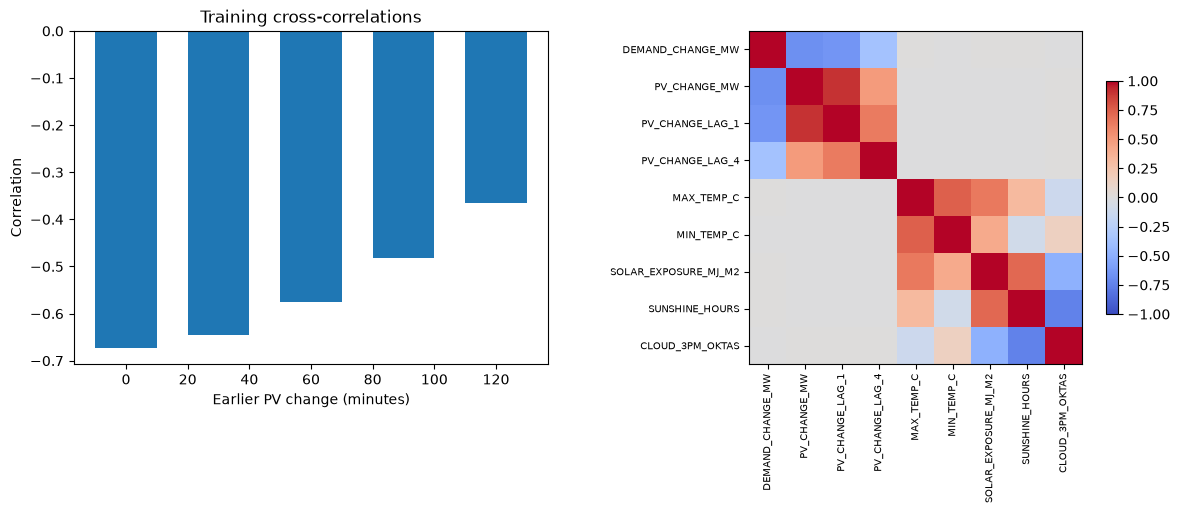

Common explanatory rows: 17509 training; 720 validation


,Input,VIF
0,PV_CHANGE_MW,7.81
1,PV_CHANGE_LAG_1,11.77
2,PV_CHANGE_LAG_2,11.79
3,PV_CHANGE_LAG_3,11.78
4,PV_CHANGE_LAG_4,7.81
5,MAX_TEMP_C,3.58
6,SOLAR_EXPOSURE_MJ_M2,5.67
7,MIN_TEMP_C,4.35
8,SUNSHINE_HOURS,4.50
9,CLOUD_3PM_OKTAS,2.19


Training weather correlations:


,MAX_TEMP_C,MIN_TEMP_C,SOLAR_EXPOSURE_MJ_M2,SUNSHINE_HOURS,CLOUD_3PM_OKTAS
MAX_TEMP_C,1.00,0.75,0.64,0.32,-0.12
MIN_TEMP_C,0.75,1.00,0.41,-0.09,0.14
SOLAR_EXPOSURE_MJ_M2,0.64,0.41,1.00,0.72,-0.49
SUNSHINE_HOURS,0.32,-0.09,0.72,1.00,-0.74
CLOUD_3PM_OKTAS,-0.12,0.14,-0.49,-0.74,1.00


In [4]:
lag_columns = [f'PV_CHANGE_LAG_{lag}' for lag in range(1, 5)]
lag_correlations = []
for lag, column in enumerate(['PV_CHANGE_MW'] + lag_columns):
    pairs = train[['DEMAND_CHANGE_MW', column]].dropna()
    lag_correlations.append({'Lag (minutes)': lag * 30, 'Pairs': len(pairs),
                             'Correlation': pairs.corr().iloc[0, 1]})
lag_correlations = pd.DataFrame(lag_correlations)
display(lag_correlations.round(3))

periods = pd.cut(train['DATETIME'].dt.hour, [0, 6, 12, 18, 24], right=False,
                 labels=['00–06', '06–12', '12–18', '18–24'])
rows = []
for name, group in train.groupby(periods, observed=True):
    rows.append({'Hours': str(name), 'Pairs': group[['PV_CHANGE_MW', 'DEMAND_CHANGE_MW']].dropna().shape[0],
                 'Correlation': group['PV_CHANGE_MW'].corr(group['DEMAND_CHANGE_MW'])})
display(pd.DataFrame(rows).round(3))

correlation_columns = ['DEMAND_CHANGE_MW', 'PV_CHANGE_MW', 'PV_CHANGE_LAG_1',
                       'PV_CHANGE_LAG_4', 'MAX_TEMP_C', 'MIN_TEMP_C',
                       'SOLAR_EXPOSURE_MJ_M2', 'SUNSHINE_HOURS', 'CLOUD_3PM_OKTAS']
figure, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(lag_correlations['Lag (minutes)'], lag_correlations['Correlation'], width=20)
axes[0].set(xlabel='Earlier PV change (minutes)', ylabel='Correlation', title='Training cross-correlations')
corr = train[correlation_columns].corr()
image = axes[1].imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
axes[1].set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=7)
axes[1].set_yticks(range(len(corr)), corr.index, fontsize=7)
figure.colorbar(image, ax=axes[1], shrink=0.7)
save_plot(figure, '05_correlations.png')


def calendar_matrix(data, time_column='DATETIME'):
    time = data[time_column]
    season = time.dt.month.map({12: 'Summer', 1: 'Summer', 2: 'Summer',
                               3: 'Autumn', 4: 'Autumn', 5: 'Autumn',
                               6: 'Winter', 7: 'Winter', 8: 'Winter',
                               9: 'Spring', 10: 'Spring', 11: 'Spring'})
    calendar = pd.DataFrame(index=data.index)
    calendar['slot'] = pd.Categorical(time.dt.hour * 2 + time.dt.minute // 30, categories=range(48))
    calendar['weekday'] = pd.Categorical(time.dt.dayofweek, categories=range(7))
    calendar['season'] = pd.Categorical(season, categories=['Summer', 'Autumn', 'Winter', 'Spring'])
    return pd.get_dummies(calendar, drop_first=True, dtype=float)


# Use training medians only. Weather is not used in the forecast models below.
weather_medians = train[weather_columns].median()
solar_mean = train['SOLAR_EXPOSURE_MJ_M2'].mean()


def explanatory_matrix(data):
    columns = ['PV_CHANGE_MW', 'MAX_TEMP_C', 'SOLAR_EXPOSURE_MJ_M2'] + lag_columns
    values = data[columns].copy()
    values[['MAX_TEMP_C', 'SOLAR_EXPOSURE_MJ_M2']] = values[['MAX_TEMP_C', 'SOLAR_EXPOSURE_MJ_M2']].fillna(weather_medians)
    values['PV_x_afternoon'] = values['PV_CHANGE_MW'] * data['DATETIME'].dt.hour.between(12, 17)
    values['PV_x_solar'] = values['PV_CHANGE_MW'] * (values['SOLAR_EXPOSURE_MJ_M2'] - solar_mean) / 10
    return sm.add_constant(pd.concat([calendar_matrix(data), values], axis=1), has_constant='add')


explanatory_required = ['DEMAND_CHANGE_MW', 'PV_CHANGE_MW'] + lag_columns
explanatory_train = train.dropna(subset=explanatory_required)
explanatory_validation = validation.dropna(subset=explanatory_required)
X_explain = explanatory_matrix(explanatory_train)
X_explain_validation = explanatory_matrix(explanatory_validation)
y_explain = explanatory_train['DEMAND_CHANGE_MW']
y_explain_validation = explanatory_validation['DEMAND_CHANGE_MW']
print('Common explanatory rows:', len(explanatory_train), 'training;', len(explanatory_validation), 'validation')

candidate_weather = ['MIN_TEMP_C', 'SUNSHINE_HOURS', 'CLOUD_3PM_OKTAS']
vif_matrix = X_explain.drop(columns=['PV_x_afternoon', 'PV_x_solar']).copy()
for column in candidate_weather:
    vif_matrix[column] = explanatory_train[column].fillna(weather_medians[column])
continuous = ['PV_CHANGE_MW'] + lag_columns + ['MAX_TEMP_C', 'SOLAR_EXPOSURE_MJ_M2'] + candidate_weather
vif_table = pd.DataFrame({'Input': continuous, 'VIF': [variance_inflation_factor(vif_matrix.to_numpy(), vif_matrix.columns.get_loc(c)) for c in continuous]})
display(vif_table.round(2))
print('Training weather correlations:')
display(daily_weather[['MAX_TEMP_C', 'MIN_TEMP_C', 'SOLAR_EXPOSURE_MJ_M2', 'SUNSHINE_HOURS', 'CLOUD_3PM_OKTAS']].corr().round(2))

## 5. Explanatory models

Fit four small OLS specifications on the same rows. Daily maximum temperature and
solar exposure are retrospective controls here, not information available throughout
the day. The interaction model allows the PV slope to differ in the afternoon and
with daily solar exposure. The solar interaction is per 10 MJ/m² above the training
mean. Its main PV coefficient refers to non-afternoon intervals at that mean.

Use HAC standard errors with 48 retained observations (roughly a day). A few rows
are excluded for missing PV/history, so this is not an exact clock-time covariance.
Check the bandwidth and day-clustered errors next week. Confidence intervals are
conditional on the specification, not adjusted for model selection.

For comparison, fit a Gaussian GAM with separate cubic smooths for PV change,
temperature and solar exposure, plus linear lag/calendar terms. Use six basis
functions per smooth and a fixed penalty of 0.1 on training-range-scaled inputs.
Clip later smooth inputs to the training bounds and report how often this happens.
The tree benchmark uses 100 boosting iterations, 15 leaves, a 0.08 learning rate,
30 observations per leaf and L2 penalty 1. No random internal validation split or
hyperparameter search is used. GAM and tree errors here are **not forecasts**.

In [5]:
def score_model(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    if actual.ndim != 1 or actual.shape != predicted.shape:
        raise ValueError('Scores need one prediction per observation.')
    errors = actual - predicted
    if len(errors) == 0 or not np.isfinite(errors).all():
        raise ValueError('Scores need matching, finite observations and predictions.')
    return {'MAE_MW': np.abs(errors).mean(), 'RMSE_MW': np.sqrt(np.mean(errors ** 2))}


def fit_gam(X, y, smooth_columns):
    lower = X[smooth_columns].min()
    span = (X[smooth_columns].max() - lower).replace(0, 1)
    scaled = (X[smooth_columns] - lower) / span
    splines = BSplines(scaled, df=[6] * len(smooth_columns), degree=[3] * len(smooth_columns))
    fitted = GLMGam(y, exog=X.drop(columns=smooth_columns), smoother=splines,
                   alpha=[0.1] * len(smooth_columns), family=sm.families.Gaussian()).fit(maxiter=50)
    return fitted, lower, span


def predict_gam(fitted_gam, X):
    fitted, lower, span = fitted_gam
    scaled = (X[lower.index] - lower) / span
    clipped = ((scaled < 0) | (scaled > 1)).any(axis=1).sum()
    print('GAM rows outside training smooth bounds:', clipped, 'of', len(X))
    return fitted.predict(exog=X.drop(columns=lower.index), exog_smooth=scaled.clip(0, 1))


def fit_tree(X, y):
    fitted = HistGradientBoostingRegressor(max_iter=100, max_leaf_nodes=15,
                learning_rate=0.08, min_samples_leaf=30, l2_regularization=1,
                early_stopping=False, random_state=42)
    return fitted.fit(X, y)


calendar_columns = ['const'] + list(calendar_matrix(explanatory_train).columns)
control_columns = calendar_columns + ['PV_CHANGE_MW', 'MAX_TEMP_C', 'SOLAR_EXPOSURE_MJ_M2']
lag_model_columns = control_columns + lag_columns
specifications = {'PV only': ['const', 'PV_CHANGE_MW'],
                  'Calendar + weather': control_columns,
                  'PV lags 30–120 min': lag_model_columns,
                  'Time + solar interactions': list(X_explain.columns)}
ols_models = {}
explanatory_results = []
for name, columns in specifications.items():
    fitted = sm.OLS(y_explain, X_explain[columns]).fit(cov_type='HAC', cov_kwds={'maxlags': 48})
    ols_models[name] = fitted
    prediction = fitted.predict(X_explain_validation[columns])
    lower, upper = fitted.conf_int().loc['PV_CHANGE_MW']
    explanatory_results.append({'Model': name, **score_model(y_explain_validation, prediction),
        'PV coefficient': fitted.params['PV_CHANGE_MW'], '95% lower': lower, '95% upper': upper,
        'Training adjusted R²': fitted.rsquared_adj})

explanatory_gam = fit_gam(X_explain[lag_model_columns], y_explain,
                          ['PV_CHANGE_MW', 'MAX_TEMP_C', 'SOLAR_EXPOSURE_MJ_M2'])
explanatory_results.append({'Model': 'GAM', **score_model(y_explain_validation,
    predict_gam(explanatory_gam, X_explain_validation[lag_model_columns]))})
explanatory_tree = fit_tree(X_explain[lag_model_columns], y_explain)
explanatory_results.append({'Model': 'Tree benchmark', **score_model(y_explain_validation,
    explanatory_tree.predict(X_explain_validation[lag_model_columns]))})
explanatory_results = pd.DataFrame(explanatory_results).set_index('Model')
display(explanatory_results.round(3))

interaction_fit = ols_models['Time + solar interactions']
interaction_terms = ['PV_CHANGE_MW', 'PV_x_afternoon', 'PV_x_solar'] + lag_columns
interaction_results = pd.concat([interaction_fit.params.rename('Coefficient'),
    interaction_fit.conf_int().rename(columns={0: '95% lower', 1: '95% upper'})], axis=1).loc[interaction_terms]
display(interaction_results.round(4))

GAM rows outside training smooth bounds: 0 of 720


,MAE_MW,RMSE_MW,PV coefficient,95% lower,95% upper,Training adjusted R²
Model,,,,,,
PV only,211.835,267.869,-0.631,-0.646,-0.615,0.454
Calendar + weather,123.314,160.535,-0.738,-0.766,-0.710,0.799
PV lags 30–120 min,123.103,160.162,-0.710,-0.743,-0.677,0.799
Time + solar interactions,122.322,159.059,-0.747,-0.785,-0.710,0.800
GAM,118.889,153.836,NaN,NaN,NaN,NaN
Tree benchmark,91.971,115.386,NaN,NaN,NaN,NaN


,Coefficient,95% lower,95% upper
PV_CHANGE_MW,-0.7474,-0.7848,-0.7101
PV_x_afternoon,0.0526,-0.0006,0.1058
PV_x_solar,0.0213,0.0010,0.0415
PV_CHANGE_LAG_1,-0.0488,-0.0731,-0.0244
PV_CHANGE_LAG_2,0.0176,0.0007,0.0345
PV_CHANGE_LAG_3,-0.0152,-0.0324,0.0019
PV_CHANGE_LAG_4,0.0121,-0.0090,0.0333


## 6. Forecasting baselines and PV-enhanced models

Predict `DEMAND_CHANGE_MW(t+1)`, not the current change. Zero change is persistence
in the demand level. The non-PV model uses current demand, current and previous
demand changes, yesterday's demand at the same clock time, and the target's calendar
fields. The PV version adds current PV, current PV change and its previous change.
No target-interval PV or observed weather is included.

The CSV does not include publication timestamps. These are rolling one-step
**pseudo-forecasts**, assuming current-interval demand and PV are already available.
Later validation/test predictions may use earlier observations from that period,
but the models are not refitted. A real-time claim needs an availability check.

Use the same complete rows for all models. Fit OLS and trees both with and without
PV, plus one PV-enhanced GAM. Keep the same GAM/tree settings as above. Rank models
by validation MAE, using RMSE only to break a tie.

Common forecast rows: 17468 training; 720 validation
Last training target: 2026-07-31 23:30:00
First validation origin / target: {'DATETIME': Timestamp('2026-07-31 23:30:00'), 'TARGET_TIME': Timestamp('2026-08-01 00:00:00')}


GAM rows outside training smooth bounds: 0 of 720


,MAE_MW,RMSE_MW
Model,,
Tree with PV,72.942,100.332
Tree without PV,74.415,100.345
GAM with PV,87.003,116.085
OLS without PV,87.934,120.401
OLS with PV,89.632,121.643
Zero change,272.858,341.470


Selected using validation only: Tree with PV


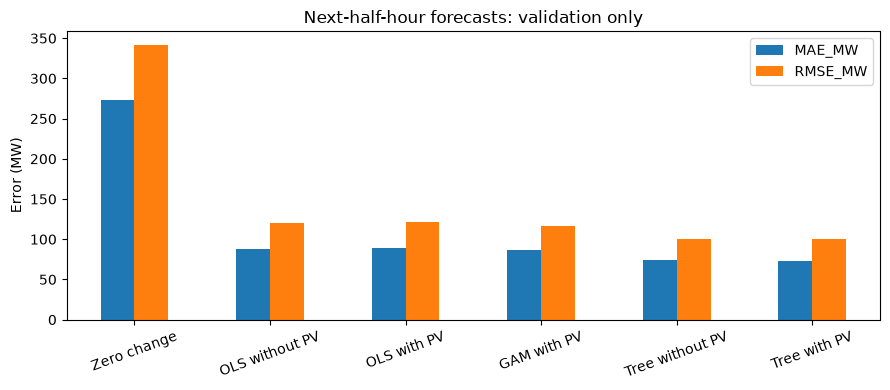

In [6]:
non_pv_columns = ['OPERATIONAL_DEMAND_MW', 'DEMAND_CHANGE_MW', 'DEMAND_CHANGE_LAG_1', 'DEMAND_LAG_48']
pv_columns = ['ROOFTOP_PV_MW', 'PV_CHANGE_MW', 'PV_CHANGE_LAG_1']
forecast_required = non_pv_columns + pv_columns + ['TARGET_CHANGE_MW', 'TARGET_TIME']
forecast_train = data.loc[data['TARGET_TIME'] < VALIDATION_START].dropna(subset=forecast_required)
forecast_validation = data.loc[(data['TARGET_TIME'] >= VALIDATION_START) & (data['TARGET_TIME'] < TEST_START)].dropna(subset=forecast_required)


def forecast_matrix(data):
    values = data[non_pv_columns + pv_columns]
    return sm.add_constant(pd.concat([calendar_matrix(data, 'TARGET_TIME'), values], axis=1), has_constant='add')


X_forecast = forecast_matrix(forecast_train)
X_forecast_validation = forecast_matrix(forecast_validation)
y_forecast = forecast_train['TARGET_CHANGE_MW']
y_forecast_validation = forecast_validation['TARGET_CHANGE_MW']
forecast_non_pv = [column for column in X_forecast if column not in pv_columns]
print('Common forecast rows:', len(forecast_train), 'training;', len(forecast_validation), 'validation')
print('Last training target:', forecast_train['TARGET_TIME'].max())
print('First validation origin / target:', forecast_validation[['DATETIME', 'TARGET_TIME']].iloc[0].to_dict())
assert forecast_train['TARGET_TIME'].max() < forecast_validation['TARGET_TIME'].min()
assert (forecast_train['TARGET_TIME'] - forecast_train['DATETIME'] == pd.Timedelta(minutes=30)).all()

forecast_ols_no_pv = sm.OLS(y_forecast, X_forecast[forecast_non_pv]).fit()
forecast_ols_pv = sm.OLS(y_forecast, X_forecast).fit()
forecast_gam = fit_gam(X_forecast, y_forecast, non_pv_columns + pv_columns)
forecast_tree_no_pv = fit_tree(X_forecast[forecast_non_pv], y_forecast)
forecast_tree_pv = fit_tree(X_forecast, y_forecast)


def forecast_predictions(X):
    return {'Zero change': np.zeros(len(X)),
            'OLS without PV': forecast_ols_no_pv.predict(X[forecast_non_pv]),
            'OLS with PV': forecast_ols_pv.predict(X),
            'GAM with PV': predict_gam(forecast_gam, X),
            'Tree without PV': forecast_tree_no_pv.predict(X[forecast_non_pv]),
            'Tree with PV': forecast_tree_pv.predict(X)}


validation_predictions = forecast_predictions(X_forecast_validation)
forecast_results = pd.DataFrame([{'Model': name, **score_model(y_forecast_validation, prediction)}
    for name, prediction in validation_predictions.items()]).set_index('Model')
display(forecast_results.sort_values(['MAE_MW', 'RMSE_MW']).round(3))
chosen_forecast = forecast_results.sort_values(['MAE_MW', 'RMSE_MW']).index[0]
print('Selected using validation only:', chosen_forecast)

figure, axis = plt.subplots(figsize=(9, 4))
forecast_results[['MAE_MW', 'RMSE_MW']].plot.bar(ax=axis, rot=20)
axis.set(title='Next-half-hour forecasts: validation only', ylabel='Error (MW)', xlabel='')
save_plot(figure, '06_validation_forecasts.png')

## 7. Diagnostics and interpretation

Keep OLS for the association estimates even if a less interpretable model has lower
validation error. Select the OLS specification by validation MAE, then inspect its
training residuals. Refit the simpler calendar/weather model on quality-1 current
and previous PV observations as a sensitivity check, not as a replacement chosen
using test performance. No official quality threshold has been confirmed yet.

Selected explanatory OLS: Time + solar interactions


1     0.683
2     0.488
4     0.172
48    0.620
Name: Residual correlation, dtype: float64

Quality sensitivity rows: 17431 of 17509
Calendar/weather PV coefficient, all / quality-1 pairs: -0.7375925099293769 -0.7356579377614828
Quality-1 HAC interval: [-0.7638389996477364, -0.7074768758752292]


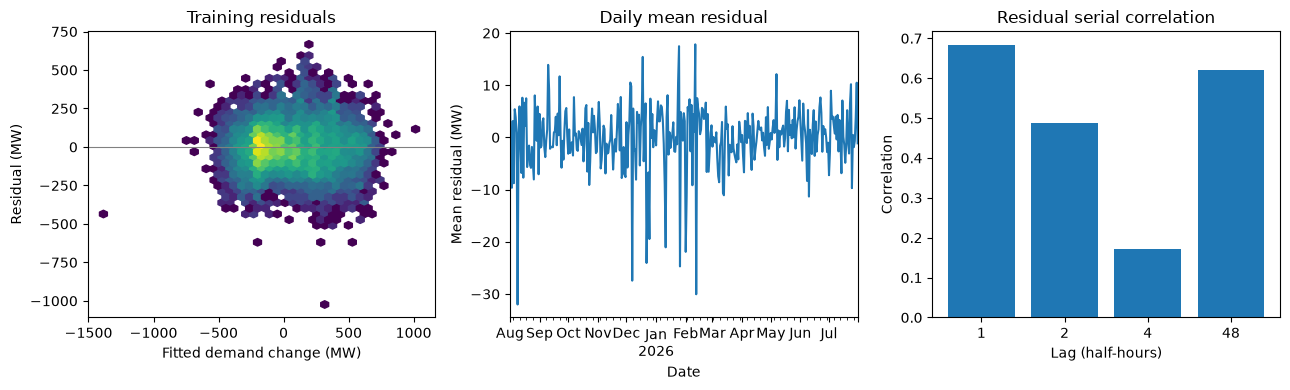

In [7]:
selected_ols_name = explanatory_results.loc[list(specifications)].sort_values(['MAE_MW', 'RMSE_MW']).index[0]
selected_ols = ols_models[selected_ols_name]
print('Selected explanatory OLS:', selected_ols_name)
residuals = pd.Series(np.asarray(selected_ols.resid), index=pd.DatetimeIndex(explanatory_train['DATETIME']))
residuals = residuals.reindex(pd.date_range(train['DATETIME'].min(), train['DATETIME'].max(), freq='30min'))
residual_correlations = pd.Series({lag: residuals.corr(residuals.shift(lag)) for lag in [1, 2, 4, 48]}, name='Residual correlation')
display(residual_correlations.round(3))

high_quality = explanatory_train['PV_QUALITY_INDICATOR'].eq(1) & explanatory_train['PREVIOUS_PV_QUALITY'].eq(1)
quality_fit = sm.OLS(y_explain.loc[high_quality], X_explain.loc[high_quality, control_columns]).fit(
    cov_type='HAC', cov_kwds={'maxlags': 48})
print('Quality sensitivity rows:', high_quality.sum(), 'of', len(high_quality))
print('Calendar/weather PV coefficient, all / quality-1 pairs:',
      ols_models['Calendar + weather'].params['PV_CHANGE_MW'], quality_fit.params['PV_CHANGE_MW'])
print('Quality-1 HAC interval:', quality_fit.conf_int().loc['PV_CHANGE_MW'].tolist())

figure, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hexbin(selected_ols.fittedvalues, selected_ols.resid, gridsize=40, mincnt=1, bins='log')
axes[0].axhline(0, color='grey', linewidth=0.8)
axes[0].set(xlabel='Fitted demand change (MW)', ylabel='Residual (MW)', title='Training residuals')
residuals.resample('D').mean().plot(ax=axes[1])
axes[1].set(xlabel='Date', ylabel='Mean residual (MW)', title='Daily mean residual')
axes[2].bar(residual_correlations.index.astype(str), residual_correlations)
axes[2].set(xlabel='Lag (half-hours)', ylabel='Correlation', title='Residual serial correlation')
save_plot(figure, '07_residuals.png')

## 8. Final test — validation choices fixed on 20 September 2026

The first run stopped before this section. Validation selected the PV-enhanced
tree (MAE 72.942 MW), compared with 74.415 MW without PV. OLS did not improve when
PV was added. The interaction OLS had the lowest validation MAE among the four
explanatory regressions, but residual correlations remained high at both 30 minutes
and 24 hours. Keep those limitations attached to the coefficient estimates.

Evaluate the frozen forecast models on 16–31 August, without refitting or changing
settings. Show the pre-specified comparators as well as the selected model. A
better score from another model here is not a reason to change the recorded choice.
This August test is now used; it cannot serve as an untouched test for Week 4.

Test rows: 768
Test targets: 2026-08-16 00:00:00 to 2026-08-31 23:30:00
GAM rows outside training smooth bounds: 0 of 768


,MAE_MW,RMSE_MW
Model,,
Zero change,224.699,282.724
OLS without PV,74.058,96.613
OLS with PV,75.138,97.644
GAM with PV,72.828,94.675
Tree without PV,66.535,88.697
Tree with PV,63.911,85.073


Recorded selection: Tree with PV
MAE improvement from adding PV to the tree (%): 3.943476387247331


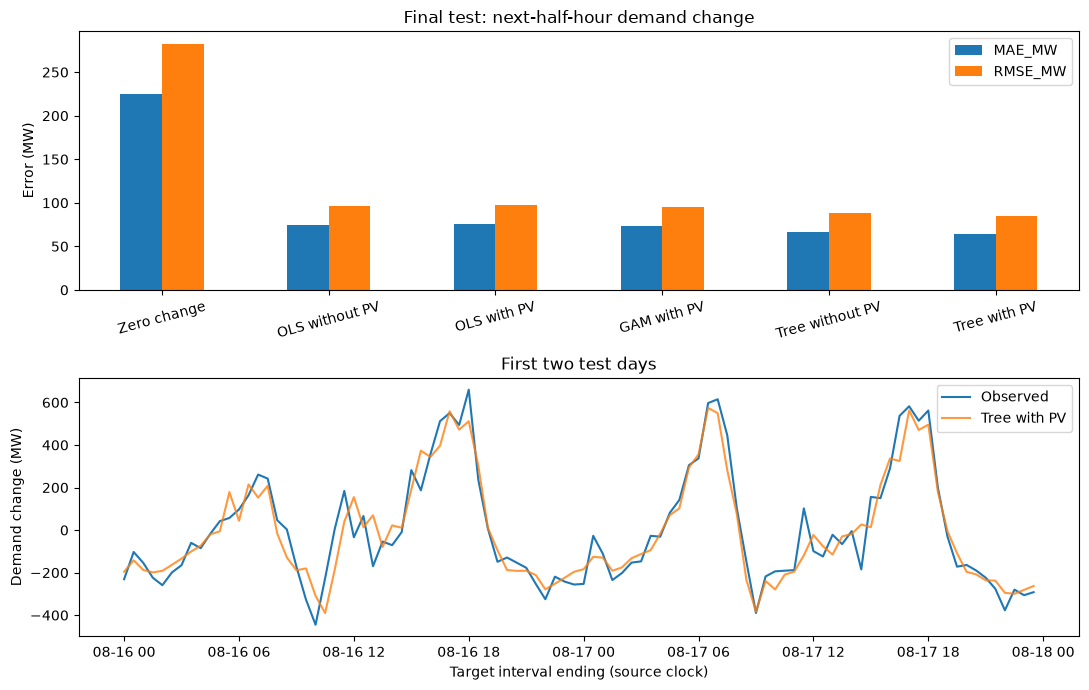

In [8]:
assert chosen_forecast == 'Tree with PV'
forecast_test = data.loc[data['TARGET_TIME'] >= TEST_START].dropna(subset=forecast_required)
X_forecast_test = forecast_matrix(forecast_test)
y_forecast_test = forecast_test['TARGET_CHANGE_MW']
print('Test rows:', len(forecast_test))
print('Test targets:', forecast_test['TARGET_TIME'].min(), 'to', forecast_test['TARGET_TIME'].max())
assert forecast_validation['TARGET_TIME'].max() < forecast_test['TARGET_TIME'].min()
test_predictions = forecast_predictions(X_forecast_test)
test_results = pd.DataFrame([{'Model': name, **score_model(y_forecast_test, prediction)}
    for name, prediction in test_predictions.items()]).set_index('Model')
display(test_results.round(3))
print('Recorded selection:', chosen_forecast)
print('MAE improvement from adding PV to the tree (%):',
      100 * (test_results.loc['Tree without PV', 'MAE_MW'] - test_results.loc['Tree with PV', 'MAE_MW'])
      / test_results.loc['Tree without PV', 'MAE_MW'])

figure, axes = plt.subplots(2, 1, figsize=(11, 7))
test_results[['MAE_MW', 'RMSE_MW']].plot.bar(ax=axes[0], rot=15)
axes[0].set(title='Final test: next-half-hour demand change', ylabel='Error (MW)', xlabel='')
first_two_days = forecast_test['TARGET_TIME'] < TEST_START + pd.Timedelta(days=2)
axes[1].plot(forecast_test.loc[first_two_days, 'TARGET_TIME'], y_forecast_test.loc[first_two_days], label='Observed')
axes[1].plot(forecast_test.loc[first_two_days, 'TARGET_TIME'],
             np.asarray(test_predictions[chosen_forecast])[first_two_days], label=chosen_forecast, alpha=0.8)
axes[1].set(xlabel='Target interval ending (source clock)', ylabel='Demand change (MW)', title='First two test days')
axes[1].legend()
save_plot(figure, '08_test_forecasts.png')

## References and working record

- Supplied data: `../data/NSW1_Historical_Modelling_Dataset_Week3.csv`,
  `Week3_Data_Dictionary.csv`, `Week3_Data_Quality_Summary.csv`,
  `Week3_EDA_and_Documentation.xlsx` and `python script.py`.
- [statsmodels GAM documentation](https://www.statsmodels.org/stable/gam.html).
- [statsmodels robust covariance documentation](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.get_robustcov_results.html).
- [scikit-learn histogram gradient boosting documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html).

See `week_3_modelling_notes.md` for the findings and `week_4_modelling_plan.md` for
follow-up work. These results describe associations in the supplied data, not the
causal effect of changing rooftop PV capacity.